<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">
<h1 style="margin: 0; color: #2c5f2d;">Random Forest to predict the Diabetes</h1>
</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## Description of the problem
This dataset originally comes from the National Institute of Diabetes and Digestive and Kidney Diseases. The goal is to predict, based on diagnostic measures, whether or not a patient has diabetes.

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Import libraries
</div>



In [77]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats
from scipy.stats import normaltest, shapiro, skew, kurtosis

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
import warnings
import joblib

warnings.filterwarnings('ignore')

# Configure plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Set random seeds for reproducibility
np.random.seed(42)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [78]:
# Configuración para visualización mejorada de DataFrames
pd.set_option('display.max_columns', None)  # Mostrar todas las columnas
pd.set_option('display.max_rows', 100)      # Mostrar hasta 100 filas
pd.set_option('display.width', None)        # Ancho automático
pd.set_option('display.max_colwidth', 100)  # Ancho máximo de columnas
pd.set_option('display.float_format', '{:.2f}'.format)  # Formato para flotantes

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">


# Step 1: Loading the CSV into a python dataset

Load the datase and specify the target variable


</div>

In [79]:
# Se cargan los datos (usando sep=';' porque el archivo usa punto y coma como separador)
df = pd.read_csv('../data/raw/diabetes.csv', sep=',')
target_variable = 'Outcome'
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.60,0.63,50,1
1,1,85,66,29,0,26.60,0.35,31,0
2,8,183,64,0,0,23.30,0.67,32,1
3,1,89,66,23,94,28.10,0.17,21,0
4,0,137,40,35,168,43.10,2.29,33,1


In [80]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.90,0.17,63,0
764,2,122,70,27,0,36.80,0.34,27,0
765,5,121,72,23,112,26.20,0.24,30,0
766,1,126,60,0,0,30.10,0.35,47,1
767,1,93,70,31,0,30.40,0.32,23,0


In [81]:
df.shape

(768, 9)

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Missing Values Analysis

</div>

In [82]:
# Para las columnas de tipo object
df.isnull().sum()


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [83]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df) > 0:
    print("Columns with missing values:")
    display(missing_df)
    
    # Visualize missing values
    plt.figure(figsize=(10, 6))
    missing_df['Percentage'].plot(kind='barh', color='coral')
    plt.title('Percentage of Missing Values by Column', fontsize=14, fontweight='bold')
    plt.xlabel('Percentage (%)')
    plt.tight_layout()
    plt.show()
else:
    print("✓ No missing values found in the dataset!")

✓ No missing values found in the dataset!


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Detect the duplicates
</div>

In [84]:
# Check for duplicate rows
print("="*70)
print("DUPLICATE ROWS DETECTION")
print("="*70)

# Count total duplicates
total_duplicates = df.duplicated().sum()
duplicate_percentage = (total_duplicates / len(df)) * 100

print(f"\nTotal duplicate rows: {total_duplicates}")
print(f"Percentage of duplicates: {duplicate_percentage:.2f}%")

if total_duplicates > 0:
    print(f"\n⚠ {total_duplicates} duplicate rows found!")
    
    # Show duplicate rows
    print("\nDuplicate rows:")
    duplicates_df = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))
    display(duplicates_df.head(20))  # Show first 20 duplicates
    
    # Option 1: Keep first occurrence
    print("\nOptions for handling duplicates:")
    print("   1. Keep first occurrence: df_clean = df.drop_duplicates(keep='first')")
    print("   2. Keep last occurrence:  df_clean = df.drop_duplicates(keep='last')")
    print("   3. Remove all duplicates: df_clean = df.drop_duplicates(keep=False)")
    
else:
    print("\n✓ No duplicate rows found in the dataset!")



DUPLICATE ROWS DETECTION

Total duplicate rows: 0
Percentage of duplicates: 0.00%

✓ No duplicate rows found in the dataset!


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Feature Type Identification
</div>

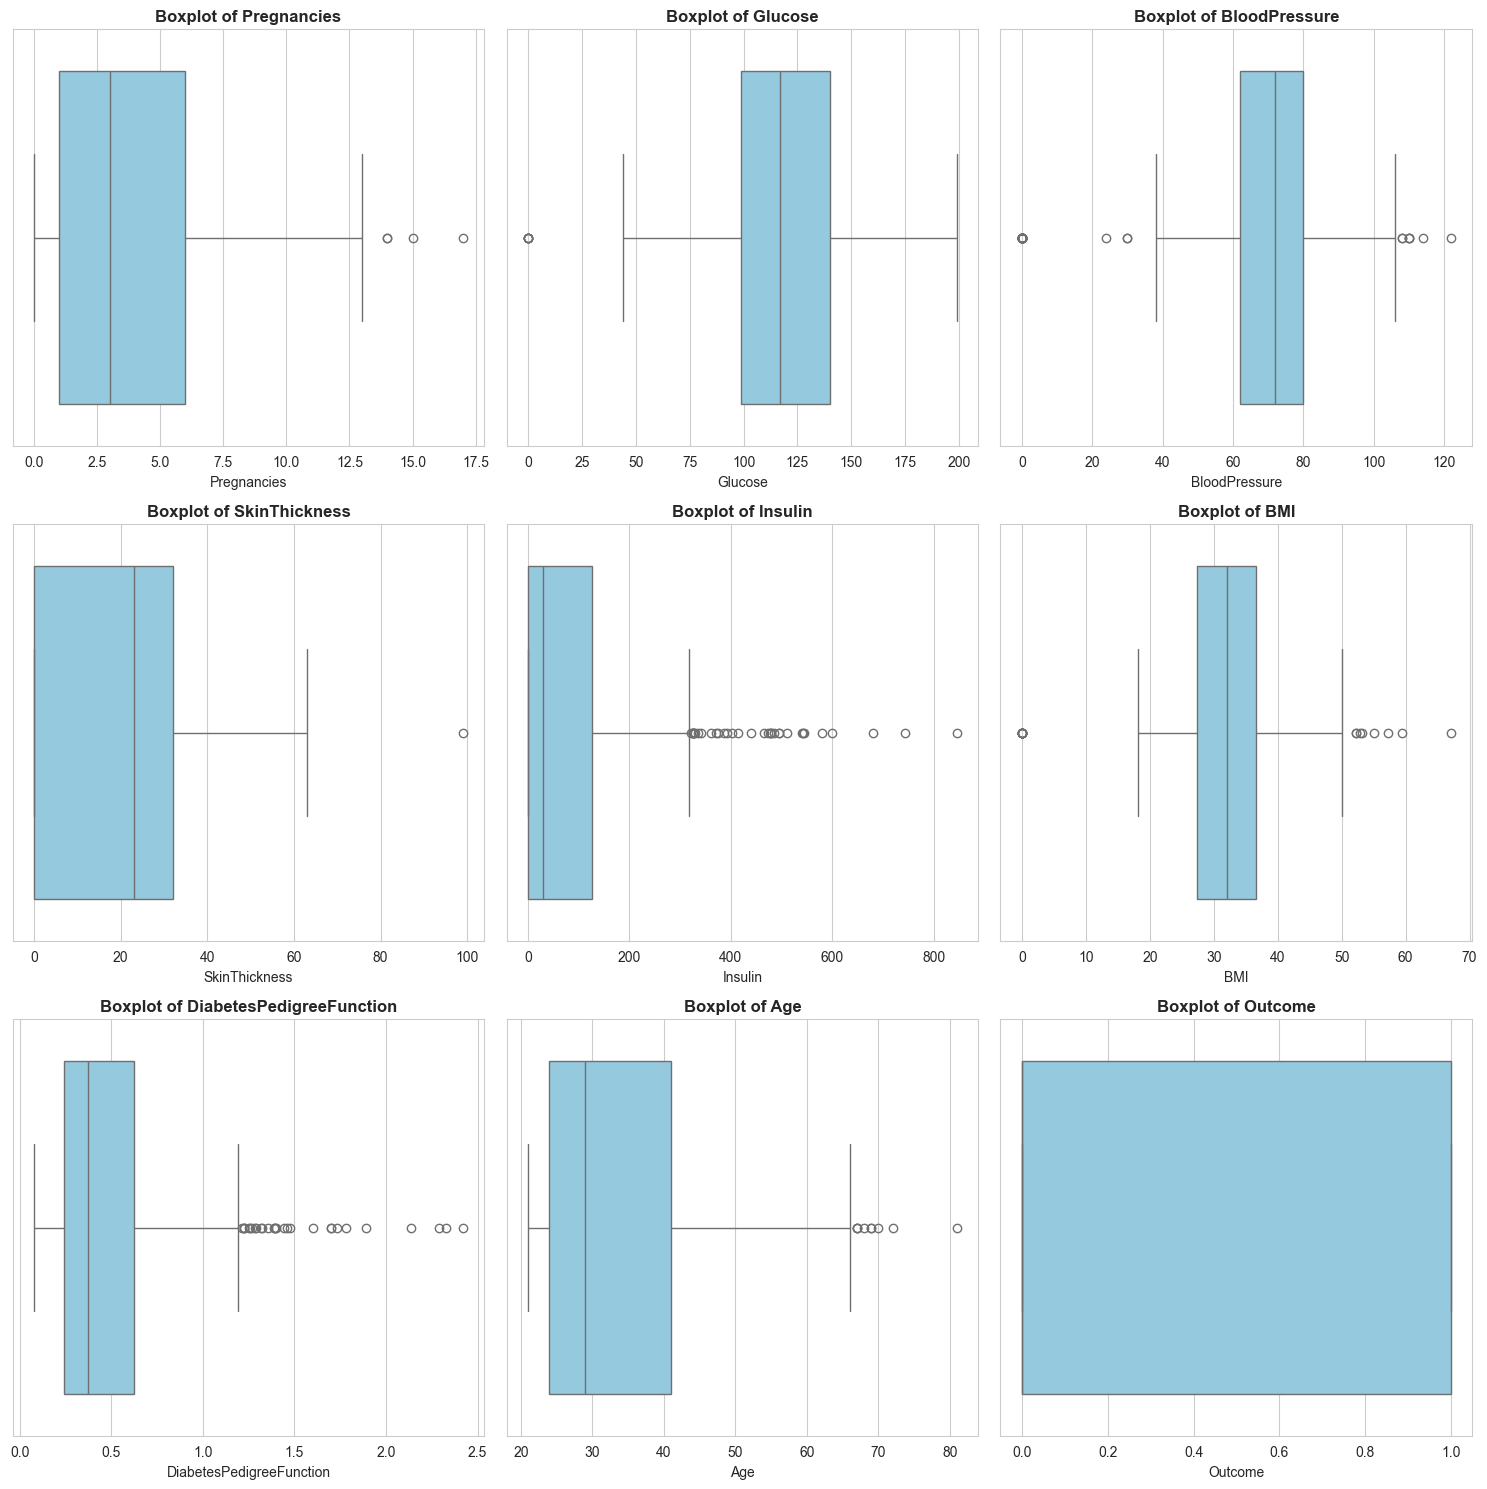

In [85]:
# Pasos para ver los outliers de cada variable numérica (3 gráficos por línea)
numeric_cols = df.select_dtypes(include=[np.number]).columns

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols  # Redondeo hacia arriba

# Crear figura con subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()  

for idx, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[idx], color='skyblue')
    axes[idx].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)

plt.tight_layout()
plt.show()

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Analayze data

* The dataframe has 369 columns and 9 variables. 

* All columns are numeric

* There isn´t any null values

##### Columns:

- Pregnancies: Most women have 0-6 pregnancies, but outliers go up to 17. Right-skewed distribution

- Glucose: Few outliers on both ends. Relatively normal distribution

- Blood Pressure: Many outliers, especially high values

- Insulin: EXTREME outliers reaching 600-800 .Most values clustered low. Highly right-skewed


- BMI: Some high outliers (60-70) .Most values between 25-40 .Few extreme obesity cases. 

- SkinThickness: Moderate outliers. Relatively symmetric. 

- DiabetesPedigreeFunction: Many small outliers .Concentrated near 0-1


- Age: Few outliers. Uniform distribution. Range 21-80 years

- Outcome: Binary (0 or 1)
</div>


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Analyze the dataset

</div>

In [86]:
# Additional statistics: skewness and kurtosis
numeric_features= df.select_dtypes(include=[np.number]).columns

stats_df = pd.DataFrame({
    'Skewness': df[numeric_features].skew(),
    'Kurtosis': df[numeric_features].kurtosis()
})
print("\nSkewness and Kurtosis:")
display(stats_df)


Skewness and Kurtosis:


,Skewness,Kurtosis
Pregnancies,0.90,0.16
Glucose,0.17,0.64
BloodPressure,-1.84,5.18
SkinThickness,0.11,-0.52
Insulin,2.27,7.21
BMI,-0.43,3.29
DiabetesPedigreeFunction,1.92,5.59
Age,1.13,0.64
Outcome,0.64,-1.60


In [87]:
# Automated Analysis of Skewness and Kurtosis
if numeric_features is not None:
    print("="*80)
    print("SKEWNESS AND KURTOSIS ANALYSIS")
    print("="*80)
    
    # Define interpretation functions
    def interpret_skewness(skew_value):
        """Interpret skewness value"""
        abs_skew = abs(skew_value)
        if abs_skew < 0.5:
            return "Fairly Symmetric-OK ", "No transformation needed"
        elif abs_skew < 1:
            return "Moderately Skewed- ALERT!! ", "Consider transformation (log, sqrt)"
        else:
            direction = "Right (positive)" if skew_value > 0 else "Left (negative)"
            return f"Highly Skewed ({direction}) ⚠⚠", "Transformation recommended (log, box-cox)"
    
    def interpret_kurtosis(kurt_value):
        """Interpret kurtosis value"""
        if abs(kurt_value) < 1:
            return "Normal Tails- OK ", "Distribution is close to normal"
        elif kurt_value > 3:
            return "Very Heavy Tails- ALERT!!", "Many outliers present"
        elif kurt_value > 1:
            return "Heavy Tails- ALERT!", "Some outliers present"
        else:
            return "Light Tails", "Fewer outliers than normal"
    
    # Analyze each feature
    transformation_needed = []
    
    for feature in numeric_features:
        skew_val = df[feature].skew()
        kurt_val = df[feature].kurtosis()
        
        skew_interp, skew_action = interpret_skewness(skew_val)
        kurt_interp, kurt_action = interpret_kurtosis(kurt_val)
        
        print(f"\n{feature}:")
        print(f"  Skewness: {skew_val:>7.3f}  → {skew_interp}")
        print(f"            Action: {skew_action}")
        print(f"  Kurtosis: {kurt_val:>7.3f}  → {kurt_interp}")
        print(f"            Action: {kurt_action}")
        
        # Track features needing transformation
        if abs(skew_val) >= 1 or kurt_val > 3:
            transformation_needed.append({
                'Feature': feature,
                'Skewness': skew_val,
                'Kurtosis': kurt_val,
                'Issue': []
            })
            if abs(skew_val) >= 1:
                transformation_needed[-1]['Issue'].append('High Skewness')
            if kurt_val > 3:
                transformation_needed[-1]['Issue'].append('Heavy Tails')
    
    # Summary and Recommendations
    print("\n" + "="*80)
    print("OVERALL RECOMMENDATIONS")
    print("="*80)
    
    if transformation_needed:
        print(f"\n⚠ {len(transformation_needed)} feature(s) may benefit from transformation:\n")
        
        for item in transformation_needed:
            print(f"• {item['Feature']}")
            print(f"  Issues: {', '.join(item['Issue'])}")
            print(f"  Suggested transformations:")
            
            # Recommend specific transformations
            if item['Skewness'] > 1:
                print(f"    - Log transformation: np.log1p(df['{item['Feature']}'])")
                print(f"    - Square root: np.sqrt(df['{item['Feature']}'])")
            elif item['Skewness'] < -1:
                print(f"    - Square: df['{item['Feature']}']**2")
                print(f"    - Exponential: np.exp(df['{item['Feature']}'])")
            
            if item['Kurtosis'] > 3:
                print(f"    - Consider outlier treatment before transformation")
            print()
        
        print("Next Steps:")
        print("   1. Investigate outliers in features with high kurtosis")
        print("   2. Apply transformations to highly skewed features")
        print("   3. Re-check distributions after transformation")
        print("   4. For Logistic Regression: transformations help but are less critical than for Linear Regression")
        
    else:
        print("\n✓ All numeric features have acceptable skewness and kurtosis!")
        print("  No transformations required for distribution normality.")
    
    print("\n" + "="*80)
else:
    print("No numeric features to analyze.")

SKEWNESS AND KURTOSIS ANALYSIS

Pregnancies:
  Skewness:   0.902  → Moderately Skewed- ALERT!! 
            Action: Consider transformation (log, sqrt)
  Kurtosis:   0.159  → Normal Tails- OK 
            Action: Distribution is close to normal

Glucose:
  Skewness:   0.174  → Fairly Symmetric-OK 
            Action: No transformation needed
  Kurtosis:   0.641  → Normal Tails- OK 
            Action: Distribution is close to normal

BloodPressure:
  Skewness:  -1.844  → Highly Skewed (Left (negative)) ⚠⚠
            Action: Transformation recommended (log, box-cox)
  Kurtosis:   5.180  → Very Heavy Tails- ALERT!!
            Action: Many outliers present

SkinThickness:
  Skewness:   0.109  → Fairly Symmetric-OK 
            Action: No transformation needed
  Kurtosis:  -0.520  → Normal Tails- OK 
            Action: Distribution is close to normal

Insulin:
  Skewness:   2.272  → Highly Skewed (Right (positive)) ⚠⚠
            Action: Transformation recommended (log, box-cox)
  Kurto

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Target Variable Analysis

Understanding the target variable is crucial for Linear Regression. We'll check:
- Distribution shape
- Normality (important assumption)
- Presence of outliers

</div>

In [88]:
# Target variable statistics
target_column='Outcome'
target_data = df[target_column]

print(f"Target Variable: {target_column}")
print("="*60)
print(f"Mean: {target_data.mean():.2f}")
print(f"Median: {target_data.median():.2f}")
print(f"Std Dev: {target_data.std():.2f}")
print(f"Min: {target_data.min():.2f}")
print(f"Max: {target_data.max():.2f}")
print(f"Range: {target_data.max() - target_data.min():.2f}")
print(f"\nSkewness: {target_data.skew():.2f}")
print(f"Kurtosis: {target_data.kurtosis():.2f}")

# Normality test
print("\nNormality Tests:")
_, shapiro_p = shapiro(target_data.dropna())
print(f"Shapiro-Wilk p-value: {shapiro_p:.4f}")
print(f"Is Normal (p > 0.05)? {shapiro_p > 0.05}")

Target Variable: Outcome
Mean: 0.35
Median: 0.00
Std Dev: 0.48
Min: 0.00
Max: 1.00
Range: 1.00

Skewness: 0.64
Kurtosis: -1.60

Normality Tests:
Shapiro-Wilk p-value: 0.0000
Is Normal (p > 0.05)? False


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">


#### Basic Statistics
Mean: 0.35 → 35% of patients in the dataset have diabetes (Outcome=1), while 65% don't (Outcome=0)

Median: 0.00 → More than half of the patients are non-diabetic (confirms class imbalance)

Min/Max: 0.00/1.00 → Binary variable (0 = No Diabetes, 1 = Has Diabetes)


#### Distribution Shape
Skewness: 0.64 → Moderately right-skewed (longer tail on the right)

Distribution is asymmetric, leaning toward 0

Kurtosis: -1.60 → Platykurtic (flatter than normal distribution)

#### Normality Test

Shapiro-Wilk p-value: 0.0000 → p < 0.05 means reject normality

Not normal

##### Key Insights:

Class Imbalance: You have a 65:35 ratio (non-diabetic:diabetic)

Not severely imbalanced, but worth noting

Decision Trees don't require normally distributed targets

This distribution is perfectly fine

The model will learn to classify these two classes

Consider using stratify=y in your train_test_split to maintain this ratio

</div>

Text(0.5, 1.0, 'Diabetes Proportion')

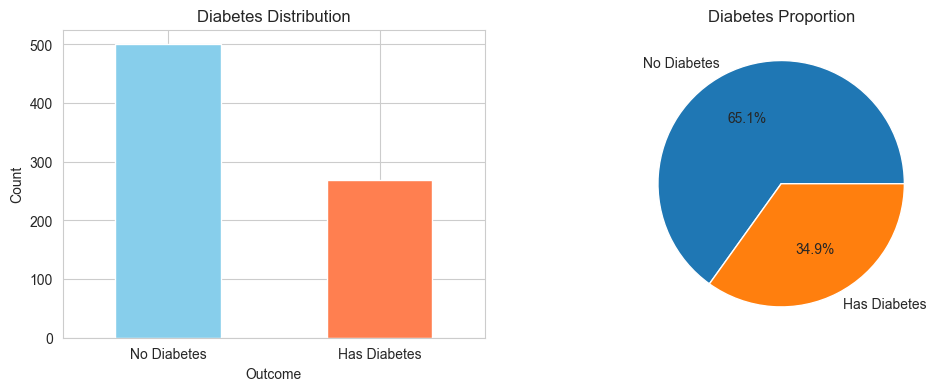

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart (better than histogram for categorical)
df['Outcome'].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'coral'])
axes[0].set_title('Diabetes Distribution')
axes[0].set_xlabel('Outcome')
axes[0].set_xticklabels(['No Diabetes', 'Has Diabetes'], rotation=0)
axes[0].set_ylabel('Count')

# Pie chart
df['Outcome'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                   labels=['No Diabetes', 'Has Diabetes'])
axes[1].set_ylabel('')
axes[1].set_title('Diabetes Proportion')

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Correlation Analysis

Correlation analysis helps identify:
- Features strongly related to the target
- Multicollinearity between features

</div

In [90]:
# Correlation matrix
correlation_matrix = df[numeric_features].corr()
print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.00,0.13,0.14,-0.08,-0.07,0.02,-0.03,0.54,0.22
Glucose,0.13,1.00,0.15,0.06,0.33,0.22,0.14,0.26,0.47
BloodPressure,0.14,0.15,1.00,0.21,0.09,0.28,0.04,0.24,0.07
SkinThickness,-0.08,0.06,0.21,1.00,0.44,0.39,0.18,-0.11,0.07
Insulin,-0.07,0.33,0.09,0.44,1.00,0.20,0.19,-0.04,0.13
BMI,0.02,0.22,0.28,0.39,0.20,1.00,0.14,0.04,0.29
DiabetesPedigreeFunction,-0.03,0.14,0.04,0.18,0.19,0.14,1.00,0.03,0.17
Age,0.54,0.26,0.24,-0.11,-0.04,0.04,0.03,1.00,0.24
Outcome,0.22,0.47,0.07,0.07,0.13,0.29,0.17,0.24,1.00


In [91]:
# Correlation with target variable
correlations = correlation_matrix[target_column].sort_values(ascending=False)
print(f"\nCorrelation with {target_column}:")
print(correlations)


Correlation with Outcome:
Outcome                    1.00
Glucose                    0.47
BMI                        0.29
Age                        0.24
Pregnancies                0.22
DiabetesPedigreeFunction   0.17
Insulin                    0.13
SkinThickness              0.07
BloodPressure              0.07
Name: Outcome, dtype: float64


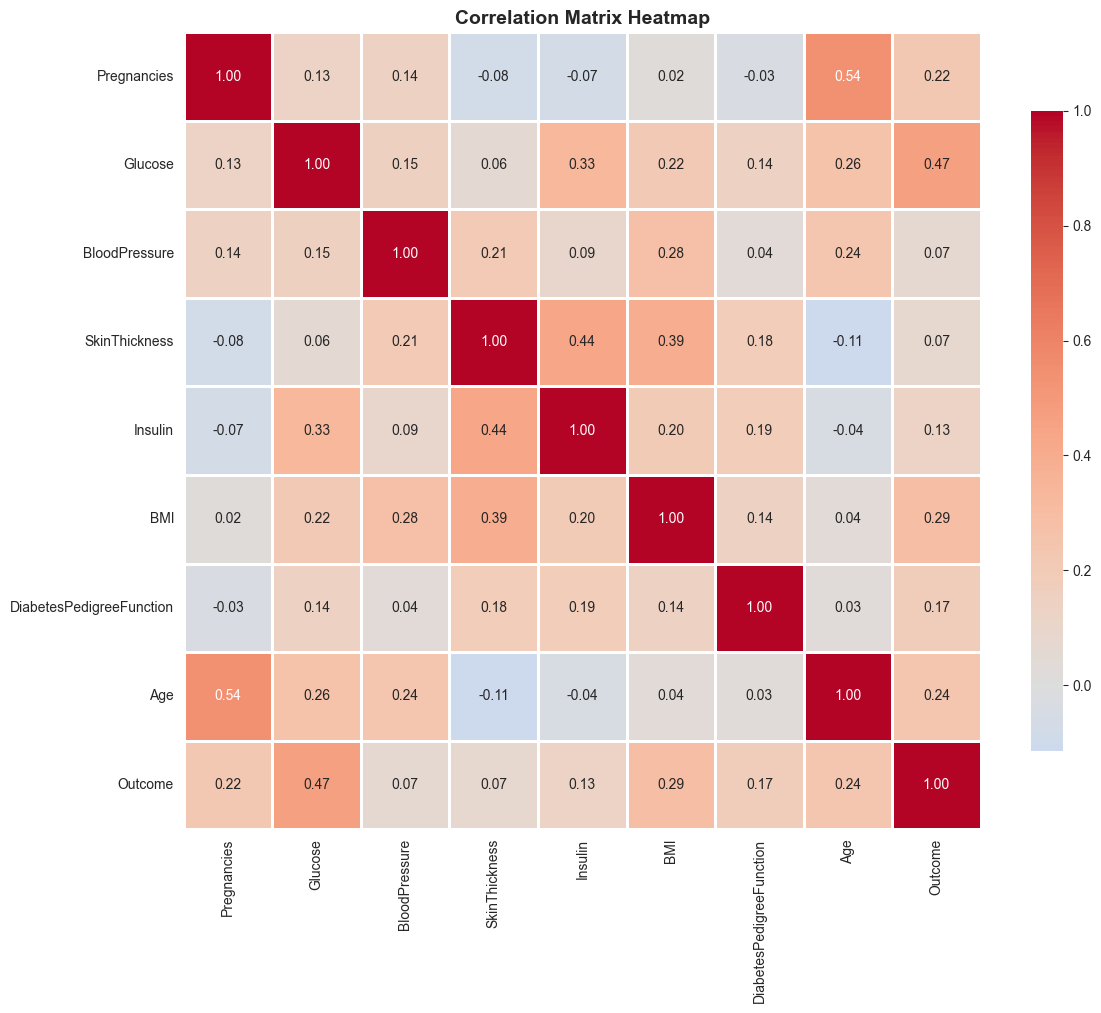


Identify strong correlations (|r| > 0.7)


In [92]:
# Visualize correlation matrix with heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8}
)
plt.title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify strong correlations
print("\n" + "="*70)
print("Identify strong correlations (|r| > 0.7)")
print("="*70)
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            print(f"• {correlation_matrix.columns[i]:20} <-> {correlation_matrix.columns[j]:20} | r = {correlation_matrix.iloc[i, j]:>6.3f}")

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

There isn´t strong correlation between features and the target variable, which is common in medical datasets. This suggests that no single feature dominates the prediction, and the model will need to learn complex interactions between features to predict diabetes effectively.

</div>

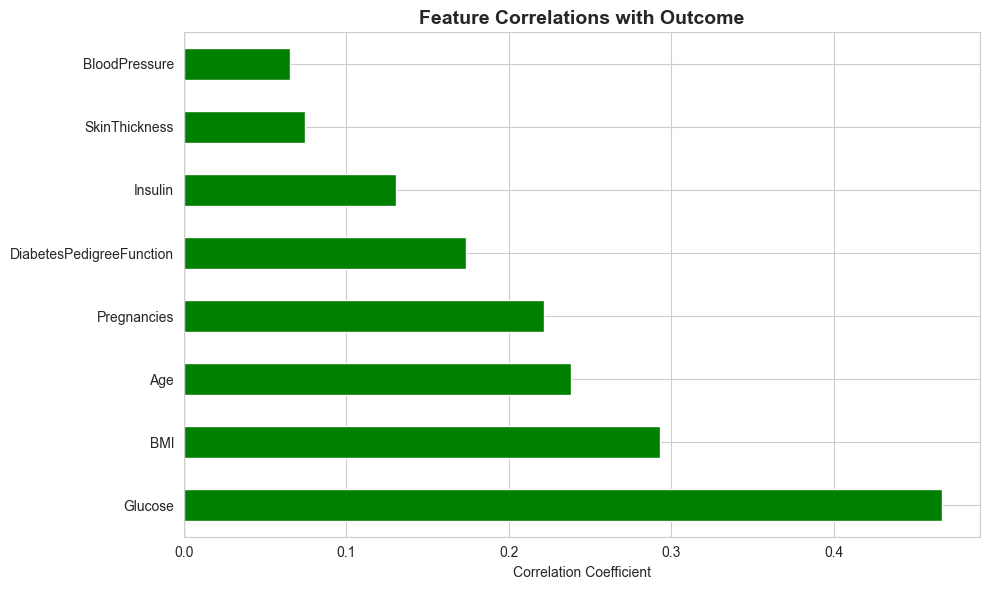

In [93]:
# Bar plot of correlations with target
target_corr = correlations[correlations.index != target_column]

plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in target_corr.values]
target_corr.plot(kind='barh', color=colors)
plt.title(f'Feature Correlations with {target_column}', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Outlier Detection

Outliers can significantly affect Linear Regression models. We'll use the IQR (Interquartile Range) method.
</div>

In [94]:
# Detect outliers using IQR method
outlier_summary = {}

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    if len(outliers) > 0:
        outlier_summary[col] = {
            'count': len(outliers),
            'percentage': (len(outliers) / len(df)) * 100,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound
        }

if outlier_summary:
    print("Outliers detected:")
    print("="*60)
    for col, info in outlier_summary.items():
        print(f"\n{col}:")
        print(f"  Count: {info['count']} ({info['percentage']:.2f}%)")
        print(f"  Bounds: [{info['lower_bound']:.2f}, {info['upper_bound']:.2f}]")
else:
    print("✓ No outliers detected using IQR method!")

Outliers detected:

Pregnancies:
  Count: 4 (0.52%)
  Bounds: [-6.50, 13.50]

Glucose:
  Count: 5 (0.65%)
  Bounds: [37.12, 202.12]

BloodPressure:
  Count: 45 (5.86%)
  Bounds: [35.00, 107.00]

SkinThickness:
  Count: 1 (0.13%)
  Bounds: [-48.00, 80.00]

Insulin:
  Count: 34 (4.43%)
  Bounds: [-190.88, 318.12]

BMI:
  Count: 19 (2.47%)
  Bounds: [13.35, 50.55]

DiabetesPedigreeFunction:
  Count: 29 (3.78%)
  Bounds: [-0.33, 1.20]

Age:
  Count: 9 (1.17%)
  Bounds: [-1.50, 66.50]


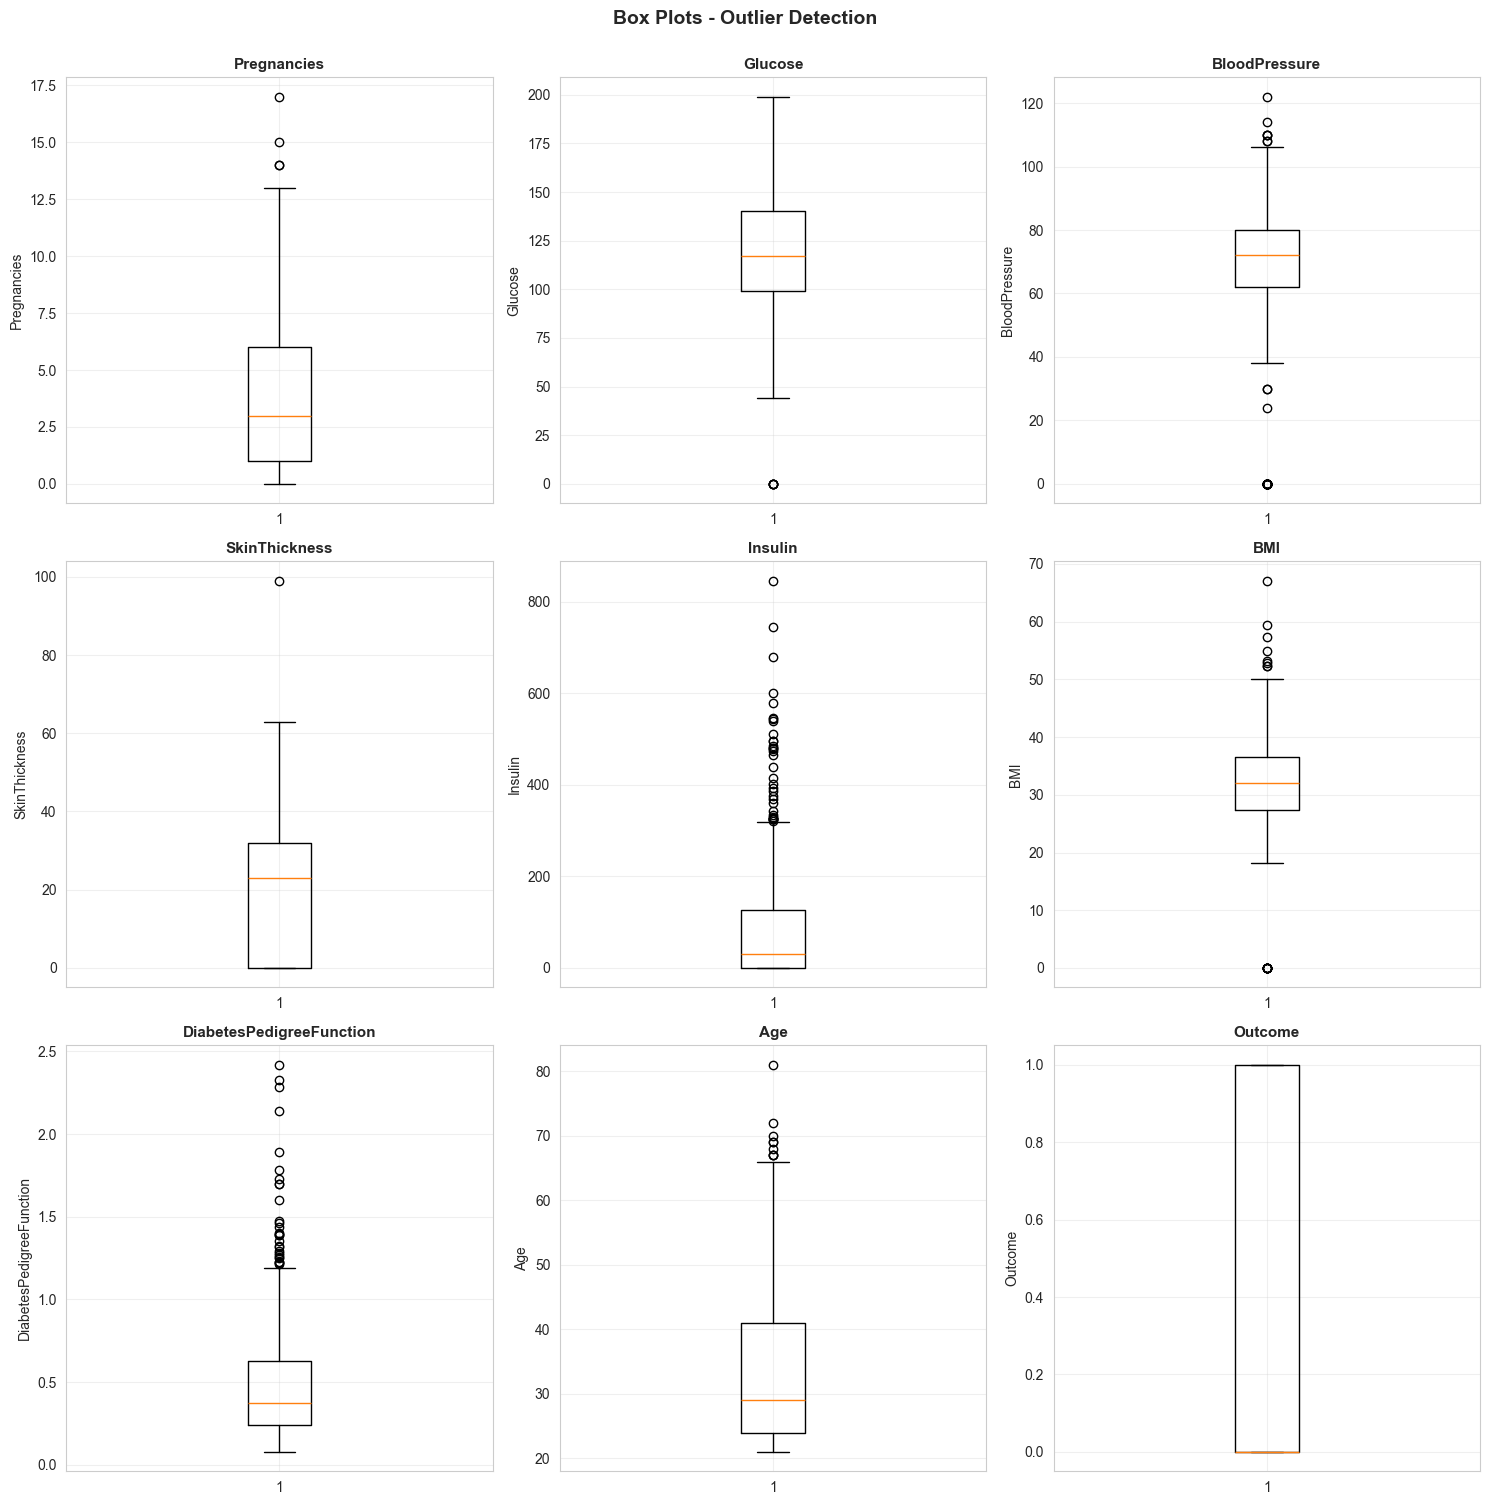

In [95]:
# Visualize outliers with box plots
n_features = len(numeric_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_features > 1 else [axes]

for idx, col in enumerate(numeric_features):
    axes[idx].boxplot(df[col].dropna(), vert=True)
    axes[idx].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel(col)
    axes[idx].grid(True, alpha=0.3)

# Hide empty subplots
for idx in range(len(numeric_features), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Box Plots - Outlier Detection', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

For Decision tree, we don´t need to remove outliers, because they are not affected by them.

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Feature Distributions

Visualizing distributions helps identify skewness and potential transformations needed.

</div>

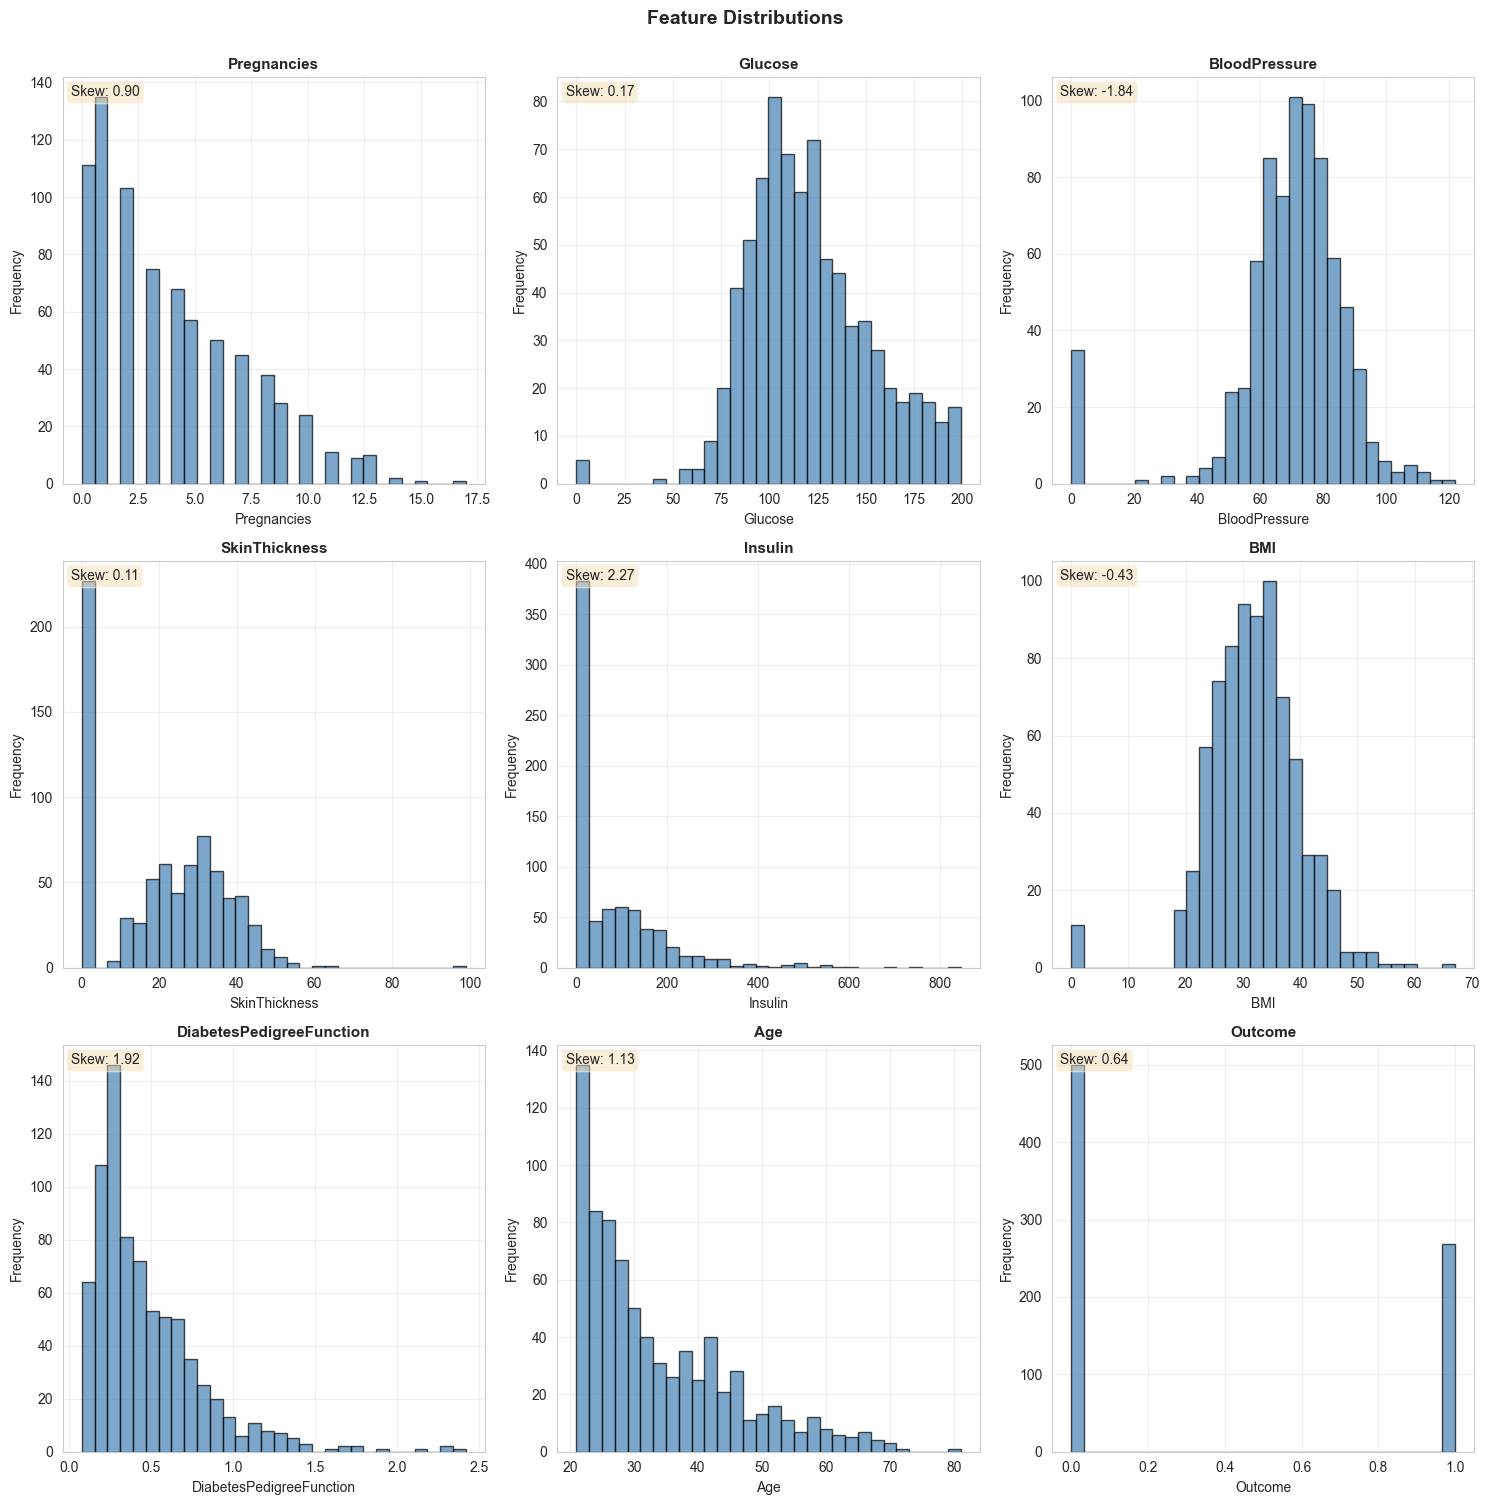

In [96]:
# Histogram for all numeric features
n_features = len(numeric_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_features > 1 else [axes]

for idx, col in enumerate(numeric_features):
    axes[idx].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)
    
    # Add skewness info
    skewness = df[col].skew()
    axes[idx].text(0.02, 0.98, f'Skew: {skewness:.2f}', 
                   transform=axes[idx].transAxes, 
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Hide empty subplots
for idx in range(len(numeric_features), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Feature vs Target Relationships

Scatter plots help visualize the relationship between each feature and the target variable.
</div>

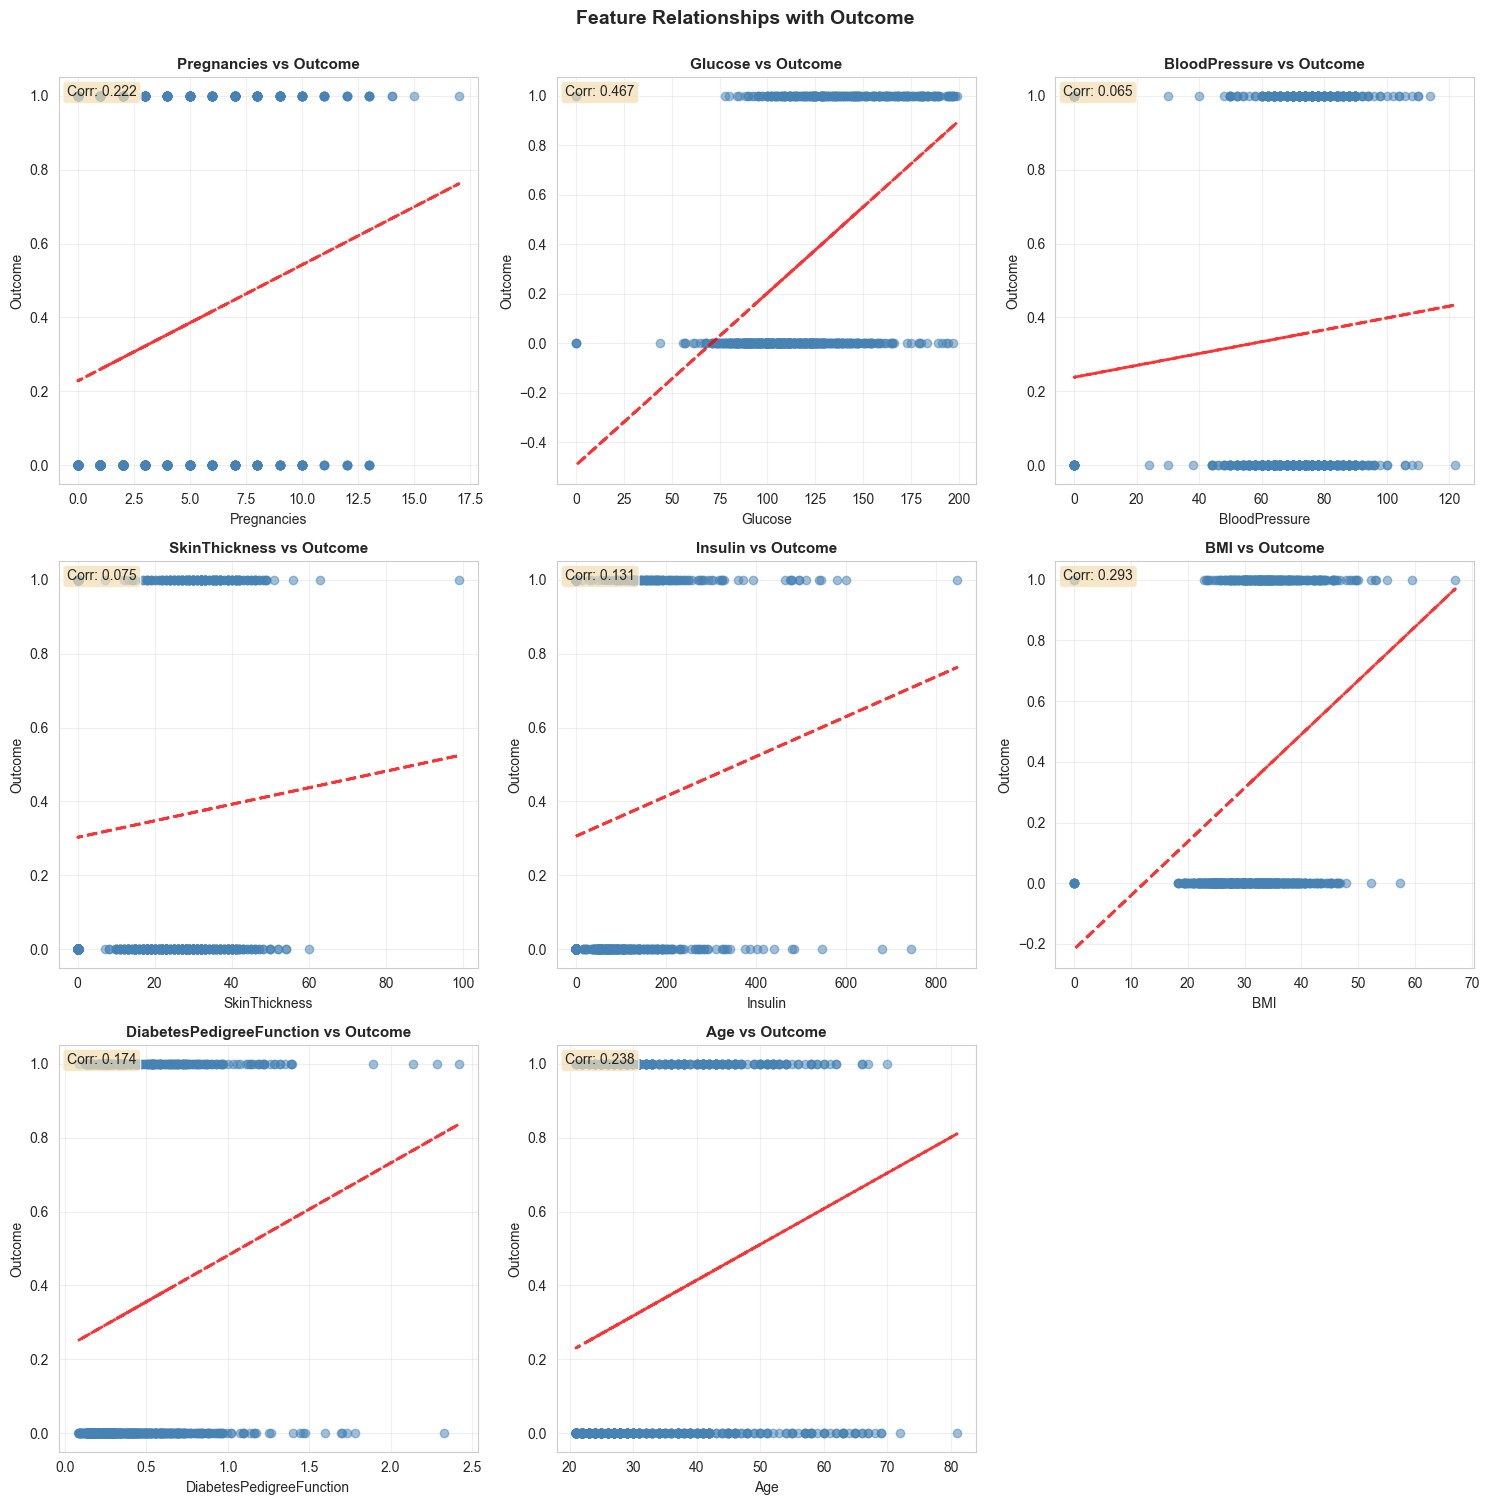

In [97]:
# Scatter plots: Features vs Target
features_to_plot = [f for f in numeric_features if f != target_column]
n_features = len(features_to_plot)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_features > 1 else [axes]

for idx, col in enumerate(features_to_plot):
    # Scatter plot
    axes[idx].scatter(df[col], df[target_column], alpha=0.5, color='steelblue')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel(target_column, fontsize=10)
    axes[idx].set_title(f'{col} vs {target_column}', fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    
    # Add trend line
    try:
        z = np.polyfit(df[col].dropna(), df[target_column].loc[df[col].dropna().index], 1)
        p = np.poly1d(z)
        axes[idx].plot(df[col], p(df[col]), "r--", alpha=0.8, linewidth=2, label='Trend')
        
        # Add correlation coefficient
        corr = df[col].corr(df[target_column])
        axes[idx].text(0.02, 0.98, f'Corr: {corr:.3f}', 
                       transform=axes[idx].transAxes, 
                       verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    except:
        pass

# Hide empty subplots
for idx in range(len(features_to_plot), len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'Feature Relationships with {target_column}', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Pairplot (Relationships Overview)

Visualize all pairwise relationships at once.

</div>

Creating pairplot for: ['Outcome', 'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin']


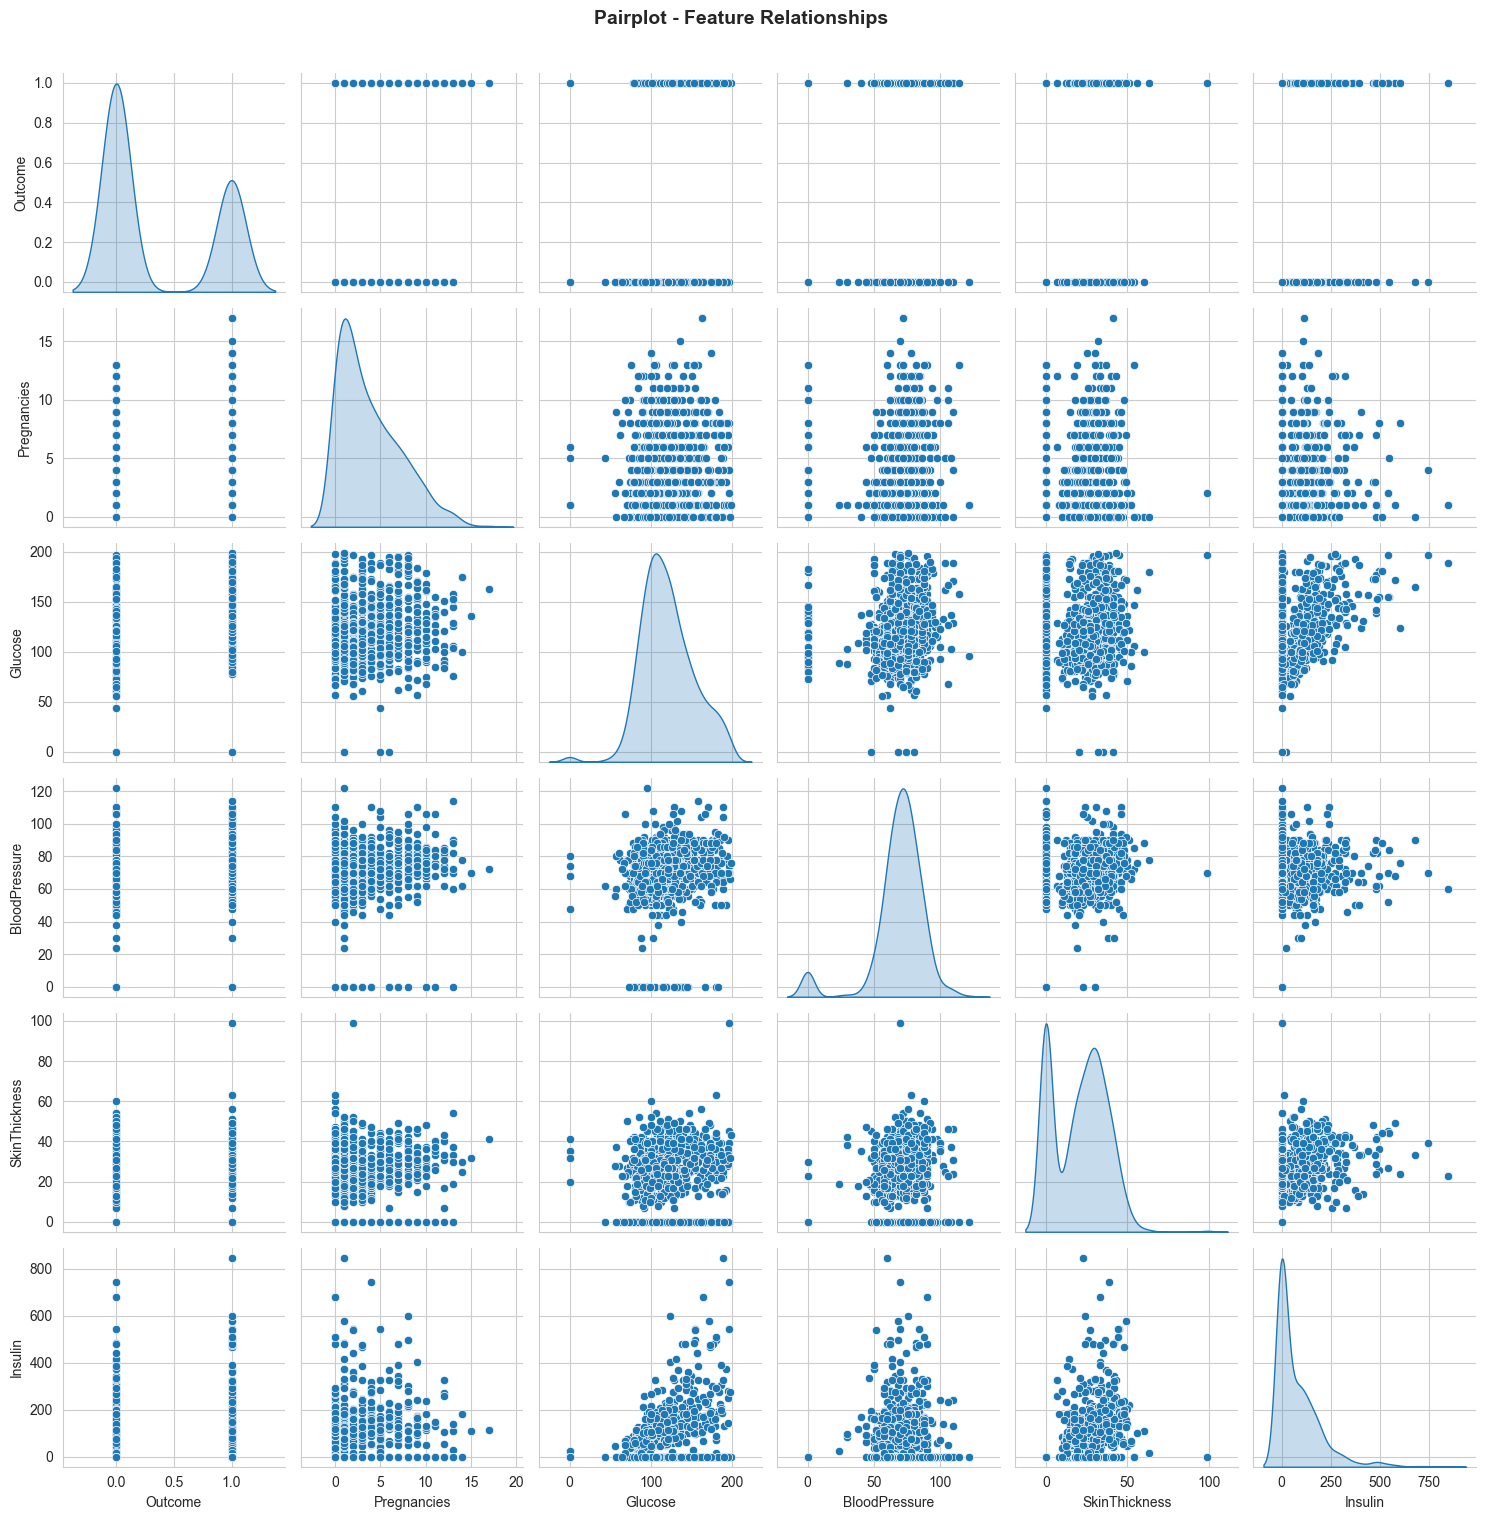

In [98]:
# Pairplot for numeric features (limit to avoid overcrowding)
features_for_pairplot = numeric_features[:6] if len(numeric_features) > 6 else numeric_features

if target_column not in features_for_pairplot:
    features_for_pairplot = [target_column] + [f for f in features_for_pairplot if f != target_column][:5]

print(f"Creating pairplot for: {features_for_pairplot}")
sns.pairplot(df[features_for_pairplot], diag_kind='kde', corner=False)
plt.suptitle('Pairplot - Feature Relationships', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Pairplot Interpretation - Diabetes Dataset

This pairplot reveals several important insights about your data:

1. **Diagonal (Variable Distributions)**
   - **BloodPressure**: Normal-ish with spike near 0 - Zero values = missing data!
   - **SkinThickness**: Massive spike at 0, then spread - Many zeros = missing data!
   - **Insulin**: HUGE spike at 0, long right tail - Many zeros = missing data!

</div>

In [99]:
# 1. Handle missing data (zeros)
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Check how many zeros
for col in cols_with_zeros:
    zero_count = (df[col] == 0).sum()
    print(f"{col}: {zero_count} zeros ({zero_count/len(df)*100:.1f}%)")



Glucose: 5 zeros (0.7%)
BloodPressure: 35 zeros (4.6%)
SkinThickness: 227 zeros (29.6%)
Insulin: 374 zeros (48.7%)
BMI: 11 zeros (1.4%)


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">


SkinThickness, Insulin, BMI needs to be impute with median
</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## 4. Data Preprocessing and Traininig with Random Tree

### Handle Missing Values

</div>

In [100]:
# Create a copy of the original dataset
df_processed = df.copy()

print("="*70)
print("DATA PREPROCESSING PIPELINE")
print("="*70)

# Step 1: Identify columns with zero values that represent missing data
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("\nStep 1: Checking zero values (missing data)")
print("-"*70)
for col in cols_to_impute:
    zero_count = (df_processed[col] == 0).sum()
    zero_pct = (zero_count / len(df_processed)) * 100
    print(f"   {col:20} {zero_count:4} zeros ({zero_pct:5.1f}%)")

# Step 2: Replace zeros with NaN
print("\nStep 2: Replacing zeros with NaN")
print("-"*70)
for col in cols_to_impute:
    df_processed[col] = df_processed[col].replace(0, np.nan)
    nan_count = df_processed[col].isnull().sum()
    print(f"   {col:20} {nan_count:4} NaN values")

print(f"\n✓ Total rows with any missing values: {df_processed.isnull().any(axis=1).sum()}")
print(f"✓ Dataset shape: {df_processed.shape}")

DATA PREPROCESSING PIPELINE

Step 1: Checking zero values (missing data)
----------------------------------------------------------------------
   Glucose                 5 zeros (  0.7%)
   BloodPressure          35 zeros (  4.6%)
   SkinThickness         227 zeros ( 29.6%)
   Insulin               374 zeros ( 48.7%)
   BMI                    11 zeros (  1.4%)

Step 2: Replacing zeros with NaN
----------------------------------------------------------------------
   Glucose                 5 NaN values
   BloodPressure          35 NaN values
   SkinThickness         227 NaN values
   Insulin               374 NaN values
   BMI                    11 NaN values

✓ Total rows with any missing values: 376
✓ Dataset shape: (768, 9)


In [101]:
# Step 3: Impute missing values with median
print("\n" + "="*70)
print("IMPUTATION STRATEGY: MEDIAN")
print("="*70)

# Calculate and display medians BEFORE imputation (excluding NaN)
print("\nMedian values used for imputation:")
print("-"*70)
medians = {}
for col in cols_to_impute:
    median_value = df_processed[col].median()
    medians[col] = median_value
    print(f"   {col:20} Median = {median_value:.2f}")

# Perform imputation
imputer = SimpleImputer(strategy='median')
df_processed[cols_to_impute] = imputer.fit_transform(df_processed[cols_to_impute])

# Verify no missing values remain
print("\nVerification after imputation:")
print("-"*70)
missing_after = df_processed.isnull().sum().sum()
print(f"   Total missing values: {missing_after}")
if missing_after == 0:
    print("   ✓ All missing values successfully imputed!")
else:
    print(f"   ⚠ Warning: {missing_after} missing values still remain")

# Display summary statistics after imputation
print("\n Dataset summary after preprocessing:")
print("-"*70)
print(f"   Total rows: {len(df_processed)}")
print(f"   Total columns: {len(df_processed.columns)}")
print(f"   Features: {len(df_processed.columns) - 1}")  # Excluding target
print(f"   Target: {target_column}")


IMPUTATION STRATEGY: MEDIAN

Median values used for imputation:
----------------------------------------------------------------------
   Glucose              Median = 117.00
   BloodPressure        Median = 72.00
   SkinThickness        Median = 29.00
   Insulin              Median = 125.00
   BMI                  Median = 32.30

Verification after imputation:
----------------------------------------------------------------------
   Total missing values: 0
   ✓ All missing values successfully imputed!

 Dataset summary after preprocessing:
----------------------------------------------------------------------
   Total rows: 768
   Total columns: 9
   Features: 8
   Target: Outcome


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Build Random Forest Model

Train an initial Random Forest with default parameters.
This model is Classification, so we will use RandomForestClassifier.
Reminder:
- Random Forest Classification for Target discrete categories
- Random Forest Regression for Target with continuos numerical values

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Train-Test Split

Split the data into training and testing sets while maintaining class distribution.

</div>

In [102]:
# Separate features and target
X = df_processed.drop(target_column, axis=1)
y = df_processed[target_column]

print("="*70)
print("TRAIN-TEST SPLIT")
print("="*70)

print(f"\n📊 Original dataset:")
print(f"   Features (X): {X.shape}")
print(f"   Target (y): {y.shape}")
print(f"\n   Target distribution:")
print(f"   - Class 0 (No Diabetes): {(y == 0).sum()} ({(y == 0).sum()/len(y)*100:.1f}%)")
print(f"   - Class 1 (Has Diabetes): {(y == 1).sum()} ({(y == 1).sum()/len(y)*100:.1f}%)")

# Split data with stratification to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Maintains class distribution
)

print(f"\nAfter split (80% train, 20% test):")
print("-"*70)
print(f"\n   Training set:")
print(f"   - Size: {X_train.shape[0]} samples")
print(f"   - Class 0: {(y_train == 0).sum()} ({(y_train == 0).sum()/len(y_train)*100:.1f}%)")
print(f"   - Class 1: {(y_train == 1).sum()} ({(y_train == 1).sum()/len(y_train)*100:.1f}%)")

print(f"\n   Testing set:")
print(f"   - Size: {X_test.shape[0]} samples")
print(f"   - Class 0: {(y_test == 0).sum()} ({(y_test == 0).sum()/len(y_test)*100:.1f}%)")
print(f"   - Class 1: {(y_test == 1).sum()} ({(y_test == 1).sum()/len(y_test)*100:.1f}%)")

print("\n✓ Data split complete with stratification!")

TRAIN-TEST SPLIT

📊 Original dataset:
   Features (X): (768, 8)
   Target (y): (768,)

   Target distribution:
   - Class 0 (No Diabetes): 500 (65.1%)
   - Class 1 (Has Diabetes): 268 (34.9%)

After split (80% train, 20% test):
----------------------------------------------------------------------

   Training set:
   - Size: 614 samples
   - Class 0: 400 (65.1%)
   - Class 1: 214 (34.9%)

   Testing set:
   - Size: 154 samples
   - Class 0: 100 (64.9%)
   - Class 1: 54 (35.1%)

✓ Data split complete with stratification!


In [103]:
# Create and train baseline Decision Tree
print("="*70)
print("RANDOM FOREST MODEL")
print("="*70)

# Initialize model
dt_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Train baseline model
print("Training baseline Random Forest model...")
dt_baseline.fit(X_train, y_train)
print("✓ Training complete!")

# Get predictions
y_train_pred = dt_baseline.predict(X_train)
y_test_pred = dt_baseline.predict(X_test)

# Basic evaluation
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"\nBaseline Model - Train Accuracy: {train_accuracy:.4f}")
print(f"Baseline Model - Validation Accuracy: {test_accuracy:.4f}")

print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORT (Test Set)")
print("="*70)
print("\n", classification_report(y_test, y_test_pred, 
                                   target_names=['Outcome 0 (No Diabetes)', 'Outcome 1 (Has Diabetes)']))


RANDOM FOREST MODEL
Training baseline Random Forest model...
✓ Training complete!

Baseline Model - Train Accuracy: 1.0000
Baseline Model - Validation Accuracy: 0.7792

DETAILED CLASSIFICATION REPORT (Test Set)

                           precision    recall  f1-score   support

 Outcome 0 (No Diabetes)       0.80      0.88      0.84       100
Outcome 1 (Has Diabetes)       0.73      0.59      0.65        54

                accuracy                           0.78       154
               macro avg       0.76      0.74      0.75       154
            weighted avg       0.77      0.78      0.77       154



<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">


### Hyperparameter Optimization (Random Forest)


We tune the model using `GridSearchCV` with stratified cross-validation and optimize for F1 score.


</div>

In [105]:
# Hyperparameter tuning with GridSearchCV
print("="*70)
print("HYPERPARAMETER OPTIMIZATION - RANDOM FOREST")
print("="*70)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}

rf_for_tuning = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf_for_tuning,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\n✓ Hyperparameter tuning complete!")
print(f"Best CV F1-score: {grid_search.best_score_:.4f}")
print("Best parameters:")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")

rf_optimized = grid_search.best_estimator_

HYPERPARAMETER OPTIMIZATION - RANDOM FOREST
Fitting 5 folds for each of 432 candidates, totalling 2160 fits

✓ Hyperparameter tuning complete!
Best CV F1-score: 0.7058
Best parameters:
   class_weight: balanced
   max_depth: 5
   max_features: log2
   min_samples_leaf: 1
   min_samples_split: 5
   n_estimators: 300


BASELINE VS OPTIMIZED MODEL COMPARISON


,Model,Train_Accuracy,Test_Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Baseline RF,1.00,0.78,0.73,0.59,0.65,0.82
1,Optimized RF,0.85,0.75,0.62,0.74,0.67,0.82



Classification Report - Optimized Model
                          precision    recall  f1-score   support

 Outcome 0 (No Diabetes)       0.84      0.75      0.79       100
Outcome 1 (Has Diabetes)       0.62      0.74      0.67        54

                accuracy                           0.75       154
               macro avg       0.73      0.75      0.73       154
            weighted avg       0.76      0.75      0.75       154



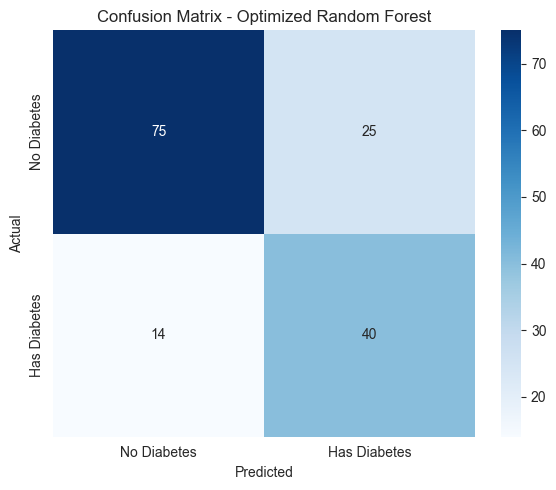

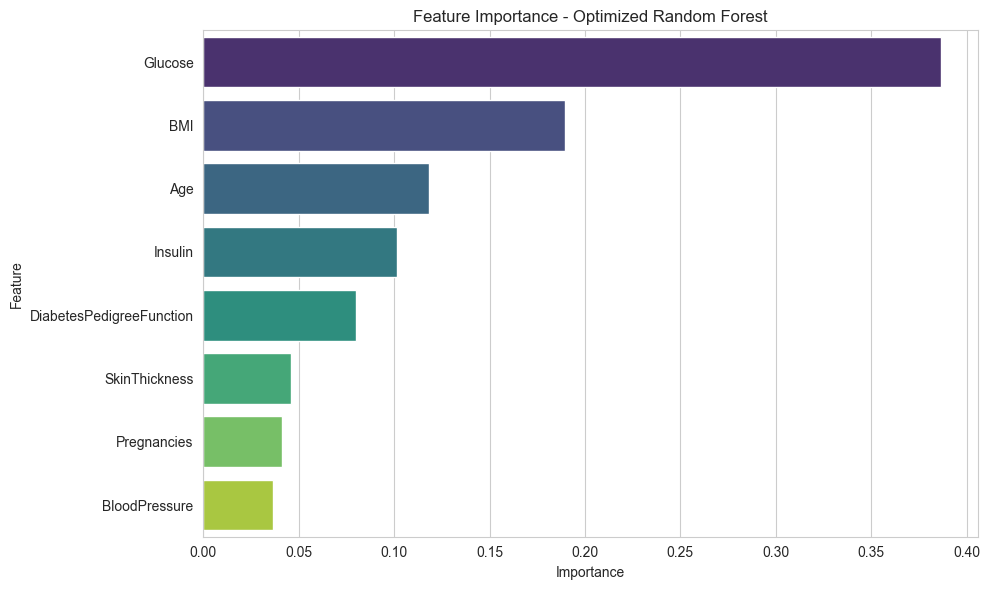

In [106]:
# Evaluate optimized model and compare with baseline
y_train_pred_opt = rf_optimized.predict(X_train)
y_test_pred_opt = rf_optimized.predict(X_test)

# Probabilities for ROC-AUC
y_test_proba_base = dt_baseline.predict_proba(X_test)[:, 1]
y_test_proba_opt = rf_optimized.predict_proba(X_test)[:, 1]

comparison_df = pd.DataFrame({
    'Model': ['Baseline RF', 'Optimized RF'],
    'Train_Accuracy': [
        accuracy_score(y_train, y_train_pred),
        accuracy_score(y_train, y_train_pred_opt)
    ],
    'Test_Accuracy': [
        accuracy_score(y_test, y_test_pred),
        accuracy_score(y_test, y_test_pred_opt)
    ],
    'Precision': [
        precision_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred_opt)
    ],
    'Recall': [
        recall_score(y_test, y_test_pred),
        recall_score(y_test, y_test_pred_opt)
    ],
    'F1_Score': [
        f1_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred_opt)
    ],
    'ROC_AUC': [
        roc_auc_score(y_test, y_test_proba_base),
        roc_auc_score(y_test, y_test_proba_opt)
    ]
})

print("="*70)
print("BASELINE VS OPTIMIZED MODEL COMPARISON")
print("="*70)
display(comparison_df.round(4))

print("\nClassification Report - Optimized Model")
print("="*70)
print(classification_report(
    y_test,
    y_test_pred_opt,
    target_names=['Outcome 0 (No Diabetes)', 'Outcome 1 (Has Diabetes)']
))

# Confusion matrix for optimized model
cm_opt = confusion_matrix(y_test, y_test_pred_opt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Has Diabetes'],
            yticklabels=['No Diabetes', 'Has Diabetes'])
plt.title('Confusion Matrix - Optimized Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Feature importance from optimized model
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_optimized.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance - Optimized Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Error Analysis

In [1]:
# Identify misclassified samples
misclassified = y_test != y_test_pred
n_misclassified = misclassified.sum()

print(f"Total misclassified samples: {n_misclassified} out of {len(y_test)} ({n_misclassified/len(y_test)*100:.2f}%)")

if n_misclassified > 0:
    print("\nSample of misclassified predictions:")
    misclassified_indices = np.where(misclassified)[0][:5]
    for idx in misclassified_indices:
        print(f"  Actual: {y_test.iloc[idx]}, Predicted: {y_test_pred[idx]}")


NameError: name 'y_test' is not defined